加载Q表：q_table.pkl

开始训练500轮（每10轮打印一次）
防御无攻击惩罚值：-0.5
轮次：  10 | 近10轮平均奖励：-32.90 | 探索率：0.975
轮次：  20 | 近10轮平均奖励：-19.00 | 探索率：0.950
轮次：  30 | 近10轮平均奖励： -1.40 | 探索率：0.925
轮次：  40 | 近10轮平均奖励： -2.30 | 探索率：0.900
轮次：  50 | 近10轮平均奖励：-23.80 | 探索率：0.875
轮次：  60 | 近10轮平均奖励：-10.75 | 探索率：0.850
轮次：  70 | 近10轮平均奖励：-15.90 | 探索率：0.825
轮次：  80 | 近10轮平均奖励： 17.90 | 探索率：0.800
轮次：  90 | 近10轮平均奖励： 63.25 | 探索率：0.775
轮次： 100 | 近10轮平均奖励： 45.90 | 探索率：0.750
轮次： 110 | 近10轮平均奖励：-69.50 | 探索率：0.725
轮次： 120 | 近10轮平均奖励：-26.30 | 探索率：0.700
轮次： 130 | 近10轮平均奖励： 47.45 | 探索率：0.675
轮次： 140 | 近10轮平均奖励： 21.05 | 探索率：0.650
轮次： 150 | 近10轮平均奖励：  0.95 | 探索率：0.625
轮次： 160 | 近10轮平均奖励： 35.75 | 探索率：0.600
轮次： 170 | 近10轮平均奖励： -0.25 | 探索率：0.575
轮次： 180 | 近10轮平均奖励： -6.15 | 探索率：0.550
轮次： 190 | 近10轮平均奖励： 42.05 | 探索率：0.525
轮次： 200 | 近10轮平均奖励： 49.60 | 探索率：0.500
轮次： 210 | 近10轮平均奖励：-26.35 | 探索率：0.475
轮次： 220 | 近10轮平均奖励： 10.10 | 探索率：0.450
轮次： 230 | 近10轮平均奖励：  1.45 | 探索率：0.425
轮次： 240 | 近10轮平均奖励： 11.15 | 探索率：0.400
轮次： 250 | 近10轮平均奖励： 11.45 | 探索率：0.375

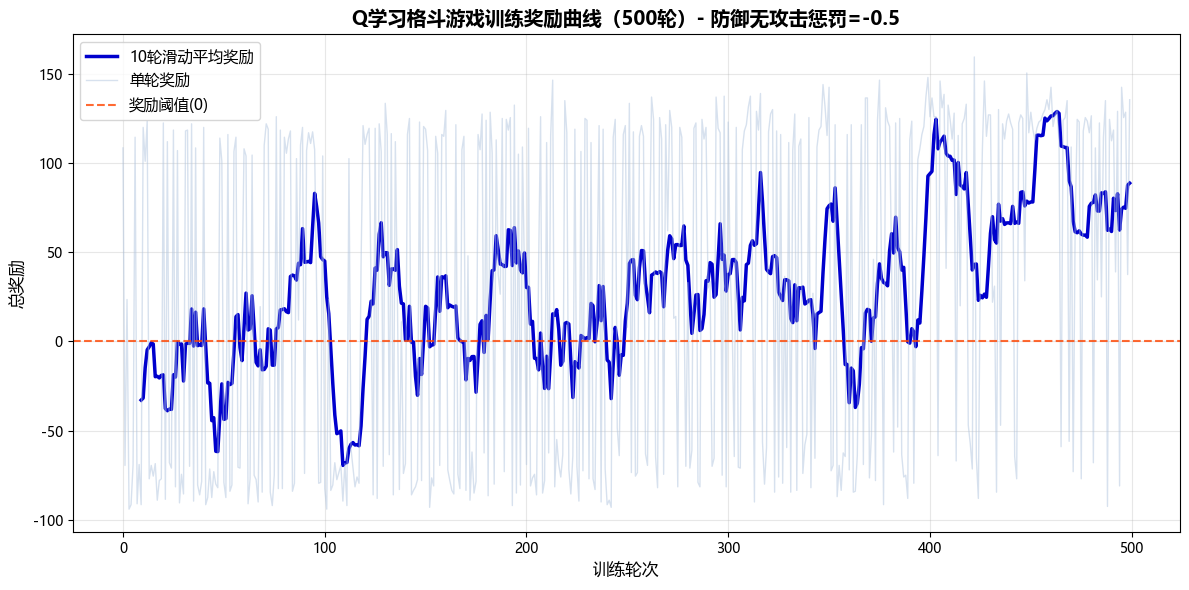

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from typing import Tuple, List, Dict


class QLearningFighter:
    """Q学习格斗智能体"""
    # 核心配置常量
    ACTIONS: List[str] = ["闪避", "格挡", "招架", "轻击", "破防", "重击"]
    ACTION_PROPS: Dict[int, Tuple[int, int]] = {
        0: (2, 1),  # 闪避：速度加成、体力消耗（防御动作）
        1: (3, 0),  # 格挡：速度加成、体力消耗（防御动作）
        2: (2, 2),  # 招架：速度加成、体力消耗（防御动作）
        3: (2, 1),  # 轻击：速度加成、体力消耗（攻击动作）
        4: (2, 1),  # 破防：速度加成、体力消耗（攻击动作）
        5: (1, 2)   # 重击：速度加成、体力消耗（攻击动作）
    }
    HP_RANGE = [1, 2, 3, 4, 5]
    STA_RANGE = [1, 2, 3, 4, 5]
    SPD_RANGE = [1, 2, 3]
    SPD_TAGS = ["自己快", "对方慢", "无"]

    def __init__(self,
                 q_table_path="q_table.pkl",
                 alpha=0.2,
                 gamma=0.95,
                 epsilon=1.0,
                 epsilon_decay=0.0025,
                 epsilon_min=0.015,
                 max_turns=50,
                 win_reward=100,
                 lose_penalty=-80,
                 small_reward=2.0,
                 small_penalty=-2.0,
                 defense_no_attack_penalty=-0.5):
        # 超参数初始化
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.max_turns = max_turns

        # 奖励体系
        self.win_reward = win_reward
        self.lose_penalty = lose_penalty
        self.small_reward = small_reward
        self.small_penalty = small_penalty
        self.defense_no_attack_penalty = defense_no_attack_penalty

        # 数据存储
        self.q_table_path = q_table_path
        self.q_table: Dict = {}
        self.train_rewards: List[float] = []

        # 初始化Q表
        self._init_q_table()

    def _init_q_table(self):
        """初始化/加载Q表"""
        if os.path.exists(self.q_table_path):
            with open(self.q_table_path, 'rb') as f:
                self.q_table = pickle.load(f)
            print(f"加载Q表：{self.q_table_path}")
        else:
            # 生成全状态空间的Q表
            for s_hp in self.HP_RANGE:
                for s_sta in self.STA_RANGE:
                    for s_spd in self.SPD_RANGE:
                        for o_hp in self.HP_RANGE:
                            for o_sta in self.STA_RANGE:
                                for o_spd in self.SPD_RANGE:
                                    for tag in self.SPD_TAGS:
                                        self.q_table[(s_hp, s_sta, s_spd, o_hp, o_sta, o_spd, tag)] = [0.0] * 6

    def save_q_table(self):
        """保存Q表"""
        with open(self.q_table_path, 'wb') as f:
            pickle.dump(self.q_table, f)
        print(f"保存Q表：{self.q_table_path}")

    def select_action(self, state: Tuple, is_agent=True) -> int:
        """动作选择（ε-贪心+敌方规则）"""
        if is_agent:
            # 智能体：ε-贪心策略
            if np.random.rand() < self.epsilon:
                return np.random.choice(6)
            return np.argmax(self.q_table[state])
        else:
            # 敌方：规则化随机策略（还原历史逻辑）
            o_hp, o_sta, o_spd = state
            probs = np.array([0.15, 0.15, 0.15, 0.2, 0.2, 0.15])
            if o_hp <= 2:
                probs[[0, 1, 2]] *= 1.8
                probs[[3, 4, 5]] *= 0.5
            if o_spd == 3:
                probs[5] *= 2.0
            if o_sta <= 2:
                probs[[2, 5]] *= 0.1
            probs /= probs.sum()  # 概率归一化
            return np.random.choice(6, p=probs)

    def fight_step(self, state: Tuple, a_act: int, o_act: int) -> Tuple[float, Tuple, bool]:
        """核心对抗逻辑"""
        s_hp, s_sta, s_spd, o_hp, o_sta, o_spd, tag = state
        reward = 0.0
        done = False
        
        # 定义防御动作：闪避(0)/格挡(1)/招架(2)
        defense_actions = [0, 1, 2]
        # 定义攻击动作：轻击(3)/破防(4)/重击(5)
        attack_actions = [3, 4, 5]
        
        # 判定条件：
        # 1. AI选择了防御动作 2. 敌方未选择攻击动作 3. AI消耗了体力（格挡体力消耗为0，不惩罚）
        if (a_act in defense_actions) and (o_act not in attack_actions) and (self.ACTION_PROPS[a_act][1] > 0):
            reward += self.defense_no_attack_penalty
            # 可选：打印调试信息（训练时可查看惩罚触发情况）
            # print(f"触发防御无攻击惩罚：AI动作={self.ACTIONS[a_act]}, 敌方动作={self.ACTIONS[o_act]}, 惩罚值={self.defense_no_attack_penalty}")

        # ===================== 2. 基础属性计算 =====================
        # 体力消耗与惩罚判定
        s_sta_new = max(1, s_sta - self.ACTION_PROPS[a_act][1])
        o_sta_new = max(1, o_sta - self.ACTION_PROPS[o_act][1])
        s_penalty = (s_sta - self.ACTION_PROPS[a_act][1]) <= 0
        o_penalty = (o_sta - self.ACTION_PROPS[o_act][1]) <= 0
        
        # 最终速度（动作+基础速度）
        s_final_spd = s_spd + self.ACTION_PROPS[a_act][0]
        o_final_spd = o_spd + self.ACTION_PROPS[o_act][0]
        
        # 临时血量（避免中途修改原始值）
        s_hp_temp, o_hp_temp = s_hp, o_hp

        # ===================== 3. 对抗规则 =====================
        # 同动作同速度互伤规则
        if a_act == o_act and s_final_spd == o_final_spd:
            if a_act == 3:  # 双方轻击
                s_hp_temp -= 1
                o_hp_temp -= 1
            elif a_act == 5:  # 双方重击
                s_hp_temp -= 2
                o_hp_temp -= 2
        else:
            # 智能体攻击奖励逻辑
            if a_act == 5:  # 重击
                if o_act in [3, 4] and o_final_spd >= s_final_spd:
                    reward += self.small_penalty  # 重击被反制
                elif o_act == 1:
                    o_hp_temp -= 1
                    reward += self.small_reward   # 重击打格挡
                elif s_final_spd >= o_final_spd + 1:
                    o_hp_temp -= 2
                    reward += self.small_reward * 2  # 重击成功
            elif a_act == 2 and o_act in [3, 5] and s_final_spd >= o_final_spd:
                o_hp_temp -= 1
                reward += self.small_reward * 2  # 招架成功
            elif a_act == 0 and o_act in [3, 5] and s_final_spd >= o_final_spd:
                reward += self.small_reward * 1.5  # 闪避成功
            elif a_act == 4:  # 破防
                if (o_act in [2, 0, 5] and s_final_spd >= o_final_spd) or (o_act == 3 and s_final_spd > o_final_spd):
                    reward += self.small_reward * 2  # 破防成功

            # 敌方攻击惩罚逻辑
            if o_act == 3 and o_final_spd > s_final_spd:
                s_hp_temp -= 1
                reward += self.small_penalty  # 被轻击命中
            elif o_act == 5 and o_final_spd >= s_final_spd + 1:
                s_hp_temp -= 2
                reward += self.small_penalty * 2  # 被重击命中
            elif o_act == 2 and a_act in [3, 5] and o_final_spd >= s_final_spd:
                s_hp_temp -= 1
                reward += self.small_penalty  # 被招架反制

            # 格挡重击特殊惩罚
            if a_act == 1 and o_act == 5:
                s_sta_new -= 2
                s_hp_temp -= 1
                reward += self.small_penalty * 2  # 格挡重击掉体力+血
            if o_act == 1 and a_act == 5:
                o_sta_new -= 2
                o_hp_temp -= 1
                reward += self.small_reward * 2  # 敌方格挡我方重击

        # 体力超限惩罚
        if s_penalty:
            s_hp_temp -= 1
            reward += self.small_penalty
        if o_penalty:
            o_hp_temp -= 1
            reward += self.small_reward

        # 体力回复
        s_sta_new = min(5, s_sta_new + 1)
        o_sta_new = min(5, o_sta_new + 1)

        # ===================== 4. 胜负判定 =====================
        s_hp_final = max(0, s_hp_temp)
        o_hp_final = max(0, o_hp_temp)
        if s_hp_final <= 0:
            reward += self.lose_penalty
            done = True
        if o_hp_final <= 0:
            reward += self.win_reward
            done = True

        # ===================== 5. 速度标签动态生成 =====================
        next_tag = "无"  # 默认标签
        # 规则1：破防成功 → 自己快
        if a_act == 4:
            if (o_act in [2, 0, 5] and s_final_spd >= o_final_spd) or (o_act == 3 and s_final_spd > o_final_spd):
                next_tag = "自己快"
        # 规则2：招架成功 → 对方慢
        elif a_act == 2 and o_act in [3, 5] and s_final_spd >= o_final_spd:
            next_tag = "对方慢"
        # 规则3：被敌方招架/破防 → 对方慢
        elif o_act == 2 and a_act in [3, 5] and o_final_spd >= s_final_spd:
            next_tag = "对方慢"
        # 规则4：重击成功压制 → 自己快
        elif a_act == 5 and s_final_spd >= o_final_spd + 1 and o_act != 1:
            next_tag = "自己快"

        # 根据速度标签生成下一回合速度
        s_spd_next, o_spd_next = s_spd, o_spd
        if next_tag == "自己快":
            s_spd_next = 3  # 自己速度拉满
            o_spd_next = np.random.choice(self.SPD_RANGE)
        elif next_tag == "对方慢":
            s_spd_next = np.random.choice(self.SPD_RANGE)
            o_spd_next = 1  # 对方速度降到最低
        else:
            # 无标签：随机生成速度
            s_spd_next = np.random.choice(self.SPD_RANGE)
            o_spd_next = np.random.choice(self.SPD_RANGE)

        # ===================== 6. 下一状态生成 =====================
        next_state = (
            int(s_hp_final), int(s_sta_new), int(s_spd_next),
            int(o_hp_final), int(o_sta_new), int(o_spd_next),
            next_tag  # 使用动态生成的标签
        )
        # 确保下一状态在Q表中
        next_state = next_state if next_state in self.q_table else state

        return reward, next_state, done

    def train(self, episodes=500):
        """训练主循环（还原原始逻辑）"""
        print(f"\n开始训练{episodes}轮（每10轮打印一次）")
        print(f"防御无攻击惩罚值：{self.defense_no_attack_penalty}")
        for ep in range(episodes):
            # 初始化每轮状态
            s_spd_init = np.random.choice(self.SPD_RANGE)
            o_spd_init = np.random.choice(self.SPD_RANGE)
            state = (5, 5, s_spd_init, 5, 5, o_spd_init, "无")
            total_r = 0.0
            turns = 0
            done = False

            # 单轮格斗循环
            while not done and turns < self.max_turns:
                turns += 1
                a_act = self.select_action(state)
                o_act = self.select_action((state[3], state[4], state[5]), is_agent=False)
                # 执行一步对抗
                r, next_state, done = self.fight_step(state, a_act, o_act)
                total_r += r

                # Q表更新（核心公式）
                self.q_table[state][a_act] += self.alpha * (
                    r + self.gamma * np.max(self.q_table[next_state]) - self.q_table[state][a_act]
                )
                state = next_state

            # 探索率衰减
            self.epsilon = max(self.epsilon_min, self.epsilon - self.epsilon_decay)
            self.train_rewards.append(total_r)

            # 每10轮打印日志
            if (ep + 1) % 10 == 0:
                avg_r = np.mean(self.train_rewards[-10:])
                print(f"轮次：{ep+1:4d} | 近10轮平均奖励：{avg_r:6.2f} | 探索率：{self.epsilon:.3f}")

        # 训练结束：保存Q表+绘制曲线
        self.save_q_table()
        self.plot_curve()

    def plot_curve(self):
        """绘制训练曲线"""
        # 中文/减号显示配置
        plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
        plt.rcParams["axes.unicode_minus"] = False

        plt.figure(figsize=(12, 6))
        # 10轮滑动平均
        window = 10
        if len(self.train_rewards) >= window:
            smooth_rewards = np.convolve(self.train_rewards, np.ones(window)/window, mode="valid")
            plt.plot(range(window-1, len(self.train_rewards)), smooth_rewards, 
                     color='#0000CD', linewidth=2.5, label='10轮滑动平均奖励')
        # 单轮奖励
        plt.plot(self.train_rewards, color='#B0C4DE', alpha=0.5, label='单轮奖励', linewidth=1)
        # 0奖励线
        plt.axhline(y=0, color='#FF4500', linestyle='--', alpha=0.8, label='奖励阈值(0)')

        # 图表标注
        plt.xlabel('训练轮次', fontsize=12)
        plt.ylabel('总奖励', fontsize=12)
        plt.title(f'Q学习格斗游戏训练奖励曲线（500轮）- 防御无攻击惩罚={self.defense_no_attack_penalty}', fontsize=14, fontweight='bold')
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3, linestyle='-')
        plt.tight_layout()

        # 保存图片
        plt.savefig('training_curve_500.png', dpi=300, bbox_inches='tight')
        print("\n✅ 训练曲线已保存：training_curve_500.png")
        plt.show()


if __name__ == "__main__":
    # 初始化智能体
    fighter_agent = QLearningFighter(
        alpha=0.2,
        gamma=0.95,
        epsilon=1.0,
        epsilon_decay=0.0025,
        epsilon_min=0.015,
        max_turns=50,
        # 新增：防御无攻击惩罚
        defense_no_attack_penalty=-0.5
    )
    # 启动500轮训练
    fighter_agent.train(episodes=500)